__Промежуточная аттестация 3: Классификация изображений__

Задача: Вам предстоит решить стандартную задачу бинарной классификации реальных изображений, взятых с сайта CIAN.

По каждой из фотографий нужно предсказать, что изображено: фото внутреннего жилого помещения или что-либо снаружи.

Размер всех изображений не более чем 100 пикселей по длинной стороне. 

Соотношения классов в тестовой и скрытой выборке одинаково.

Датасет собирался автоматизированным способом и в нем присутствует шум, то есть некоторые изображения могут быть помечены неверно.

Данные взять из соревнования https://kaggle.com/competitions/cian-datafest-2019

Задание:
1. Создать ноутбук в Google Colab;
2. Загрузить датасет из соревнования;
3. Сделать исследование данных.
4. Посмотреть какие ширины и высоты картинки в датасете
5. Убрать шум
6. Определить неверно помеченные данные
7. Оценку качества оценивать метрикой ROC AUC и accuracy

In [1]:
from os import listdir
# import filetype
import numpy as np
from scipy import stats
from matplotlib  import  pyplot as plt
import pandas as pd
from tqdm.auto import tqdm
from skimage.io import imread
# from PIL import Image
# from skimage.color import rgba2rgb
# from skimage import feature

np.set_printoptions(precision=3)
pd.set_option('display.precision', 3)

# загружаем данные

In [2]:
# def lin_norm(img):
#     img = img.astype(float)
#     mn,mx = img.min(axis=0), img.max(axis=0)
#     return (((img-mn)/(mx-mn))*250.).round().astype(np.uint8)

def imread_(f):
    img = imread(f)
    c = img.shape[-1]
    assert len(img.shape) in (3,4)
    if c==4: return 255-img[:,:,:3], 4
    return img,c

def apply_rgb(img,f):
    assert img.shape[-1]==3
    return { f.__name__+'_'+c : f(img[:,n]) for n,c in enumerate(['R','G','B']) }

def histogram(x,bins=8,):
    return np.histogram(x,bins=bins)[0]

def img_info(f):
    img,c = imread_(f)
    w,h,_ = img.shape
    img = img.reshape(-1,3) 
    
    return ({ 
               'width': w,
              'height': h, 
            'channels': c,
       'bright_median': np.median(img.flatten()),
          'bright_std': np.std(img.flatten()),
     'bright_kurtosis': stats.kurtosis(img.flatten()), 
     'bright_skewness': stats.skew(img.flatten()), 
           #'histogram': histogram(img.flatten()), 
        }
        |apply_rgb(img,np.min)
        |apply_rgb(img,np.mean)
        |apply_rgb(img,np.median)
        |apply_rgb(img,np.max)
        |apply_rgb(img,np.std)
        |apply_rgb(img,stats.kurtosis)
        |apply_rgb(img,stats.skew)
        |apply_rgb(img,histogram)
        | { 'path': f, 'is_indoor': f.find('indoor')>=0, } 
    )

In [3]:
%%time 

data = pd.DataFrame( [ 
        img_info(f'data/{t}/{f}')
        for t in ['indoor','outdoor']
        for f in tqdm(listdir(f'data/{t}/')) 
    ])

  0%|          | 0/42169 [00:00<?, ?it/s]

  0%|          | 0/40813 [00:00<?, ?it/s]

CPU times: user 5min 47s, sys: 2.18 s, total: 5min 49s
Wall time: 5min 50s


In [4]:
display(len(data))
display(data.sample(3))

82982

,width,height,channels,bright_median,bright_std,bright_kurtosis,bright_skewness,amin_R,amin_G,amin_B,...,kurtosis_G,kurtosis_B,skew_R,skew_G,skew_B,histogram_R,histogram_G,histogram_B,path,is_indoor
39634,100,75,3,68.0,56.537,1.021,1.135,0,0,0,...,1.538,2.012,0.864,1.278,1.459,"[631, 1817, 1910, 1127, 1106, 369, 220, 320]","[1265, 2256, 1692, 1208, 420, 201, 186, 272]","[2062, 2319, 1471, 764, 282, 179, 194, 229]",data/indoor/image_1283.jpg,True
5507,100,75,3,161.0,53.738,-0.518,-0.320,0,1,2,...,0.144,-0.226,-1.031,-0.716,0.358,"[244, 247, 468, 582, 822, 1137, 1922, 2078]","[33, 110, 560, 1133, 1425, 3208, 899, 132]","[68, 414, 1326, 1911, 1805, 1037, 521, 418]",data/indoor/image_39020.jpg,True
30135,100,74,3,147.0,62.865,-1.072,-0.371,2,0,0,...,-1.129,-1.101,-0.490,-0.454,-0.437,"[267, 958, 547, 1075, 645, 1018, 2383, 507]","[502, 891, 742, 947, 566, 1389, 2050, 313]","[647, 838, 812, 861, 682, 1780, 1532, 248]",data/indoor/image_1096.jpg,True


In [5]:
data.to_pickle('tmp/data_raw.pkl')

In [6]:
list(data.columns)

['width',
 'height',
 'channels',
 'bright_median',
 'bright_std',
 'bright_kurtosis',
 'bright_skewness',
 'amin_R',
 'amin_G',
 'amin_B',
 'mean_R',
 'mean_G',
 'mean_B',
 'median_R',
 'median_G',
 'median_B',
 'amax_R',
 'amax_G',
 'amax_B',
 'std_R',
 'std_G',
 'std_B',
 'kurtosis_R',
 'kurtosis_G',
 'kurtosis_B',
 'skew_R',
 'skew_G',
 'skew_B',
 'histogram_R',
 'histogram_G',
 'histogram_B',
 'path',
 'is_indoor']

In [7]:
# data = pd.read_pickle('data_raw.pkl')

In [8]:
def plot_files(files,cols=5,score=None):
    rows = int(np.ceil(len(files)/cols))
    fig = plt.figure(figsize=(9,rows*2))
    for n,f in enumerate(files['path'].values):
        target = f.split('/')[1] 
        fname = f.split('/')[-1] 
        font_color = 'red' if target=='indoor' else 'blue'
        ax = fig.add_subplot(rows,cols,n+1)
        # ax.imshow( lin_norm( imread_(f)[0] ) )
        ax.imshow( imread_(f)[0] )
        ax.axis('off')
        # t = f'{target} / {fname}' if score is None else f'{target} / {score[n]:.4} / {fname}'
        t = f'{fname}' if score is None else f'{score[n]:.4} / {fname}'
        ax.set_title(t,fontdict={'fontsize':7,'color':font_color})      
    plt.tight_layout()

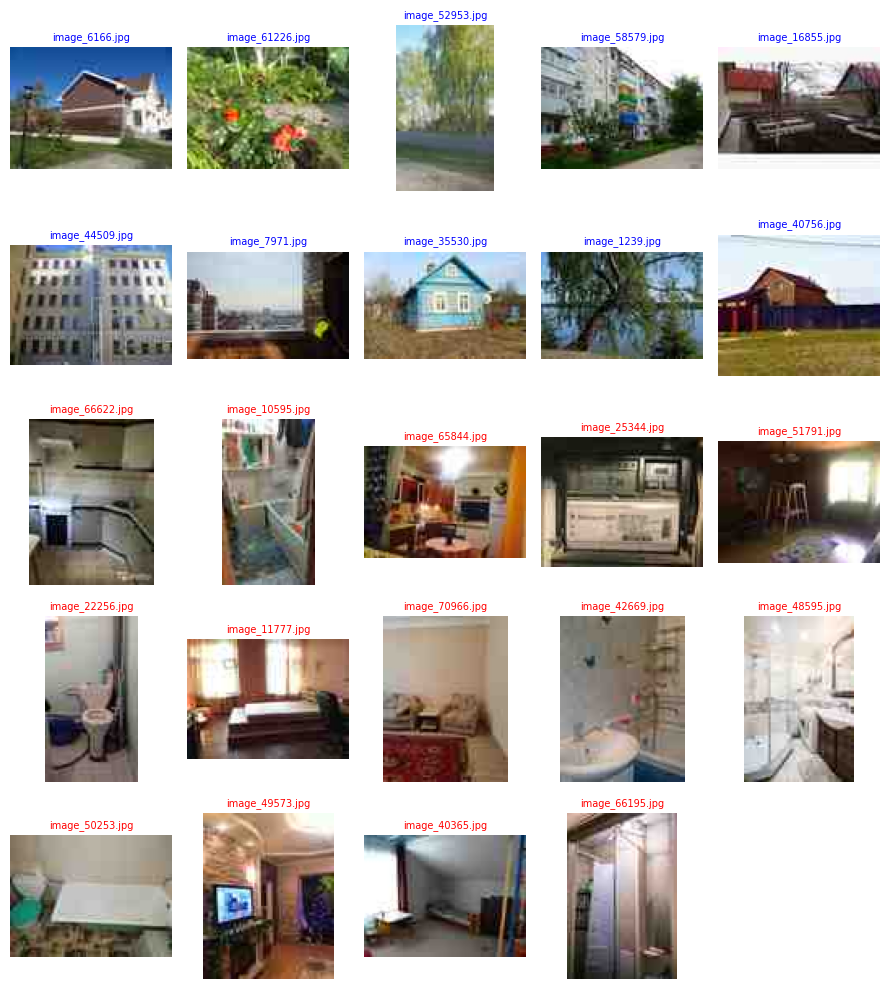

In [9]:
files = data[['is_indoor','path']].sample(24).sort_values(by='is_indoor')
plot_files(files)

# размер картинок

In [10]:
data['size_'] = data[['width','height']].apply(lambda r: '{}x{}'.format(*r),axis=1)

In [11]:
data['size_ratio'] = data['width']/data['height']

In [13]:
data.query('channels==4')[['width', 'height','channels','size_','size_ratio','path','is_indoor']]

,width,height,channels,size_,size_ratio,path,is_indoor
33076,74,100,4,74x100,0.74,data/indoor/image_33756.jpg,True
43607,74,100,4,74x100,0.74,data/outdoor/image_70825.jpg,False
77143,65,100,4,65x100,0.65,data/outdoor/image_82798.jpg,False


In [14]:
(
    data
    .groupby(['size_'])
    [['channels']]
    .count()
    .rename(columns={'channels':'count'})
    .nlargest(17,'count')
    .sort_values(by='count',ascending=False) 
    # .sort_index(ascending=True)
    .T
)

size_,75x100,100x75,66x100,56x100,100x56,74x100,100x74,100x66,100x79,68x100,67x100,70x100,71x100,100x100,69x100,60x100,48x100
count,22600,16389,13838,5137,3399,2440,1660,1535,729,687,630,581,566,492,479,474,444


# отбор признаков

In [15]:
data['target'] = data['is_indoor'].astype(int)

In [16]:
data.columns

Index(['width', 'height', 'channels', 'bright_median', 'bright_std',
       'bright_kurtosis', 'bright_skewness', 'amin_R', 'amin_G', 'amin_B',
       'mean_R', 'mean_G', 'mean_B', 'median_R', 'median_G', 'median_B',
       'amax_R', 'amax_G', 'amax_B', 'std_R', 'std_G', 'std_B', 'kurtosis_R',
       'kurtosis_G', 'kurtosis_B', 'skew_R', 'skew_G', 'skew_B', 'histogram_R',
       'histogram_G', 'histogram_B', 'path', 'is_indoor', 'size_',
       'size_ratio', 'target'],
      dtype='object')

In [17]:
fet_cols = [
# 'channels', 'size_', 'path', 'is_indoor', 'target'
# 'width', 'height','size', 
'size_ratio',    
'bright_kurtosis', 'bright_std',  'bright_median', 'bright_skewness', 
# 'amin_R', 'amin_G','amin_B', 
# 'mean_R', 'mean_G', 'mean_B', 
# 'median_R', 'median_B', 'median_G',
# 'amax_R', 'amax_G', 'amax_B', 
# 'std_R', 'std_B', 'std_G',
# 'kurtosis_R', 'kurtosis_G', 'kurtosis_B', 
# 'skew_R', 'skew_G', 'skew_B',
# 'histogram', 'histogram_R', 'histogram_G', 'histogram_B', 
]

In [18]:
# корреляция признаков
fet_corr =  data[fet_cols+['target']].corr()

In [19]:
( # корреляция признаков с target
    fet_corr
    [['target']]
    .abs()
    .sort_values('target',ascending=False)
    .style
    .format(precision=2)
    .background_gradient(cmap='rainbow')
)

,target
target,1.00
size_ratio,0.22
bright_skewness,0.21
bright_kurtosis,0.15
bright_std,0.14
bright_median,0.10


In [20]:
fet_pair_corr = ( # пары признаков с высокой корреляцией 
    fet_corr
    .reset_index()
    .melt(id_vars=['index'],value_vars=fet_corr.columns)
    .query('index!=variable') 
    .rename(columns={'index':'feature1','variable':'feature2','value':'corr'})
)

# удаляем дубликаты пар признаков с точностью до перестановки
fet_pair_corr = fet_pair_corr[ 
        fet_pair_corr[['feature1','feature2']]
        .apply(lambda d: ' '.join(sorted(set(d.values))).strip() , axis=1)
        .duplicated()
    ]

fet_pair_corr['corr_abs'] = fet_pair_corr['corr'].abs()

# пары признаков с высокой корреляцией 
display(
    fet_pair_corr
    .sort_values(by='corr_abs',ascending=False)
    .query('corr_abs>0.5')
    .drop(columns='corr_abs')
)

,feature1,feature2,corr
27,bright_median,bright_skewness,-0.873
13,bright_kurtosis,bright_std,-0.518


__выкидываем признаки с высокой (>0.9) корреляцией__

# формируем датасет

In [21]:
target = data['target'].values
display( target.shape )

(82982,)

In [22]:
index_indoor  = data.query('is_indoor').index
index_outdoor = data.query('~is_indoor').index

In [23]:
from sklearn.preprocessing import StandardScaler

x = np.hstack([
        data[fet_cols].values, 
        np.vstack(data['histogram_R'].values ),
        np.vstack(data['histogram_G'].values ),
        np.vstack(data['histogram_B'].values ),
    ])

x = StandardScaler().fit_transform(x)

x_indoor  = x[ index_indoor  ]
x_outdoor = x[ index_outdoor ]
         
display(( x.shape,x_indoor.shape,x_outdoor.shape ) )

((82982, 29), (42169, 29), (40813, 29))

# модель для выявления ошибочной разметки

_строим статистические модели (GMM) данных indoor и outdoor, с помощью которой будем оценивать датасет_

In [24]:
from sklearn.mixture import GaussianMixture

In [25]:
%%time 

# модель indoor
model_indoor = GaussianMixture(n_components=128,init_params='kmeans',max_iter=256).fit(x_indoor)
display( ( model_indoor.score(x_indoor), model_indoor.score(x_outdoor) ) )

(8.457588870119373, -7.252859321328309)

CPU times: user 8min 32s, sys: 4min 38s, total: 13min 10s
Wall time: 3min 41s


In [26]:
%%time 

# модель outdoor
model_outdoor = GaussianMixture(n_components=128,init_params='kmeans').fit(x_outdoor)
display( ( model_outdoor.score(x_indoor), model_outdoor.score(x_outdoor) ) )

(-1.1883974993133275, 5.543756943187403)

CPU times: user 5min 54s, sys: 3min 22s, total: 9min 16s
Wall time: 2min 37s


In [27]:
%%time

# считаем правдоподобие моделью indoor
data['gmm_score_indoor'] = model_indoor.score_samples(x)

# считаем правдоподобие моделью outdoor
data['gmm_score_outdoor'] = model_outdoor.score_samples(x)

CPU times: user 12.6 s, sys: 5.5 s, total: 18.1 s
Wall time: 4.85 s


In [28]:
data[['gmm_score_indoor','gmm_score_outdoor']].describe([.01,.10,.25,.50,.75,.95,.99]).T

,count,mean,std,min,1%,10%,25%,50%,75%,95%,99%,max
gmm_score_indoor,82982.0,0.731,19.101,-2024.564,-61.235,-20.789,-6.197,4.982,12.651,19.454,23.384,31.086
gmm_score_outdoor,82982.0,2.123,12.277,-221.036,-37.750,-12.303,-3.860,3.982,10.308,17.676,21.541,147.987


In [29]:
# помечаем картинки, для которых правдоподобие indoor превышает outdoor
data['predicted'] = ( data['gmm_score_indoor']>data['gmm_score_outdoor'] ).astype(int)

# неверно размеченные примеры 

7386

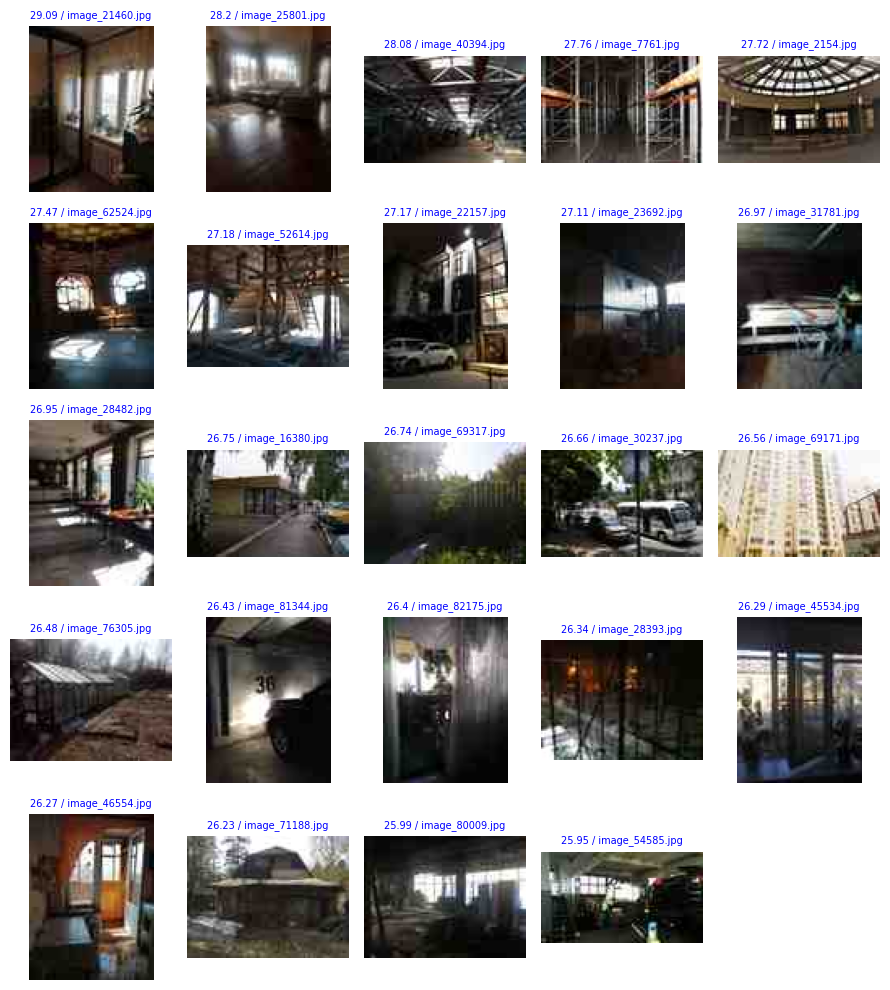

In [30]:
# картинки размеченные как outdoor, 
#     для которых правдоподобие indoor превышает outdoor

cols = ['path','gmm_score_indoor']
files = data.query('(~is_indoor) & (predicted==1)')[cols]
display(len(files))    

files = (
    files 
    .nlargest(24,'gmm_score_indoor')
    .sort_values(by=['gmm_score_indoor'],ascending=False)
)

plot_files(files,score=files['gmm_score_indoor'].values)
del files

# оценка соответствия разметки и результата модели

In [31]:
from sklearn.metrics import classification_report

print( 
    classification_report(
        y_true=target, 
        y_pred=data['predicted'].values, 
        target_names=['outdoor','indoor']
    )
)

              precision    recall  f1-score   support

     outdoor       0.89      0.82      0.85     40813
      indoor       0.84      0.90      0.87     42169

    accuracy                           0.86     82982
   macro avg       0.86      0.86      0.86     82982
weighted avg       0.86      0.86      0.86     82982



-0.5195293284371104

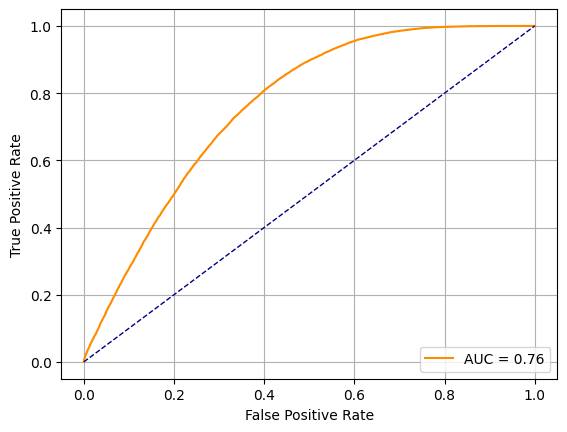

In [32]:
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(target,data['gmm_score_indoor'].values )

#  максимальное количество True Positive при минимальном количестве False Positive
optimal_threshold = thresholds[ np.argmax( np.abs(tpr-fpr) )  ]
display(optimal_threshold)

roc_auc = metrics.auc(fpr, tpr)
metrics.RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc,).plot(color='darkorange')
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
plt.grid()